In [1]:
import pandas as pd
df=pd.read_csv("ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [2]:
import matplotlib.pyplot as plt

In [6]:
df.isnull()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1431,False,False,False,False,False,False,False,False,False,False,False
1432,False,False,False,False,False,False,False,False,False,False,False
1433,False,False,False,False,False,False,False,False,False,False,False
1434,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().values.any()


np.False_

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [13]:
df.describe()


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [15]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

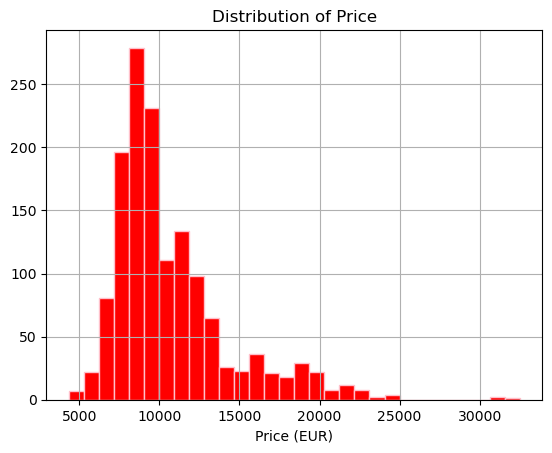

In [19]:
df['Price'].hist(bins=30, color='red', edgecolor='pink')
plt.title('Distribution of Price')
plt.xlabel('Price (EUR)')
plt.show()

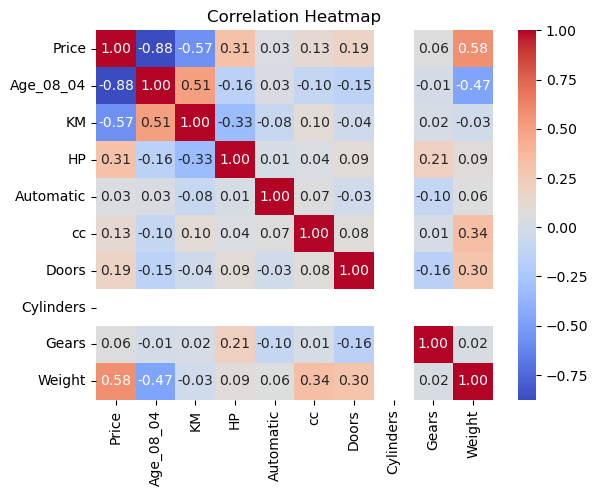

In [22]:
import numpy as np
import seaborn as sns

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

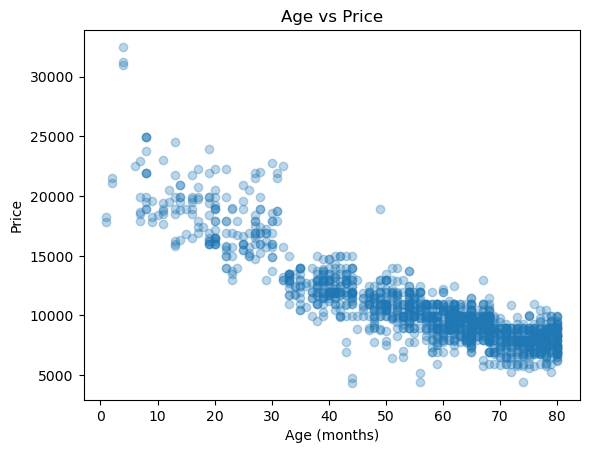

In [24]:
plt.scatter(df['Age_08_04'], df['Price'], alpha=0.3)
plt.xlabel('Age (months)')
plt.ylabel('Price')
plt.title('Age vs Price')
plt.show()

In [25]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True, dtype=int)
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,1,0
1,13750,23,72937,90,0,2000,3,4,5,1165,1,0
2,13950,24,41711,90,0,2000,3,4,5,1165,1,0
3,14950,26,48000,90,0,2000,3,4,5,1165,1,0
4,13750,30,38500,90,0,2000,3,4,5,1170,1,0


In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Price'])
Y = df['Price']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (1148, 11)
Test size : (288, 11)


# M1

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model1 = LinearRegression()
model1.fit(X_train, Y_train)
y_pred1 = model1.predict(X_test)
mse = mean_squared_error(Y_test, y_pred1)
print("Model 1: All Features")
print("Mean squared error:", np.round(mse, 2))
print("Root Mean squared error :", np.round(np.sqrt(mse), 2))
print("R square:", np.round(r2_score(Y_test, y_pred1), 2))

Model 1: All Features
Mean squared error: 2203043.82
Root Mean squared error : 1484.27
R square: 0.83


In [42]:
train_acc=model1.score(X_train,Y_train)
test_acc=model1.score(X_test,Y_test)
print(test_acc)
train_acc

0.8348888040611082


0.8702643169608926

In [35]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model1.coef_})
coef_df

,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,-8.242296e-13
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


# M2

In [44]:
top_feats = ['Age_08_04', 'KM', 'Weight', 'HP', 'cc']
model2 = LinearRegression()
model2.fit(X_train[top_feats], Y_train)
y_pred2 = model2.predict(X_test[top_feats])
mse = mean_squared_error(Y_test, y_pred2)
print("Model 2: Top 5 Features")
print("Mean squared error:", np.round(mse, 2))
print("Root Mean squared error :", np.round(np.sqrt(mse), 2))
print("R square :", np.round(r2_score(Y_test, y_pred2), 2))

Model 2: Top 5 Features
Mean squared error: 1995964.84
Root Mean squared error : 1412.79
R square : 0.85


In [41]:
train_acc = model2.score(X_train[top_feats], Y_train)
test_acc  = model2.score(X_test[top_feats], Y_test)
print("Train Accuracy:", np.round(train_acc, 2))
print("Test Accuracy:", np.round(test_acc, 2))

Train Accuracy: 0.86
Test Accuracy: 0.85


# M3

In [43]:
model3 = LinearRegression()
model3.fit(X_train[['Age_08_04', 'KM']], Y_train)
y_pred3 = model3.predict(X_test[['Age_08_04', 'KM']])
mse = mean_squared_error(Y_test, y_pred3)
print("Model 3: Age + KM Only")
print("Mean squared error:", np.round(mse, 2))
print("Root Mean squared error :", np.round(np.sqrt(mse), 2))
print("R square :", np.round(r2_score(Y_test, y_pred3), 2))

Model 3: Age + KM Only
Mean squared error: 2925606.6
Root Mean squared error : 1710.44
R square : 0.78


In [45]:
train_acc = model3.score(X_train[['Age_08_04', 'KM']], Y_train)
test_acc  = model3.score(X_test[['Age_08_04', 'KM']], Y_test)
print("Train Accuracy:", np.round(train_acc, 2))
print("Test Accuracy:", np.round(test_acc, 2))

Train Accuracy: 0.79
Test Accuracy: 0.78


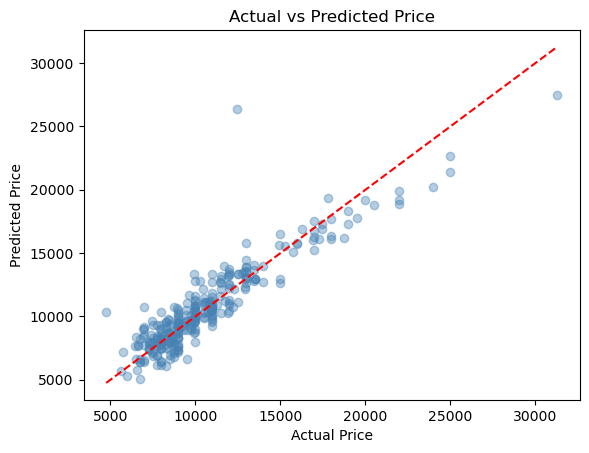

In [46]:
# Actual vs Predicted Plot (Model 1 - best model)
plt.scatter(Y_test, y_pred1, alpha=0.4, color='steelblue')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

In [47]:
# Ridge and Lasso - scale features first
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [49]:
# Ridge Regression 
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=10)
ridge.fit(X_train_sc, Y_train)
y_pred_r = ridge.predict(X_test_sc)
mse = mean_squared_error(Y_test, y_pred_r)
print("Ridge (alpha=10)")
print("Mean squared error:", np.round(mse, 2))
print("Root Mean squared error :", np.round(np.sqrt(mse), 2))
print("R square:", np.round(r2_score(Y_test, y_pred_r), 2))

Ridge (alpha=10)
Mean squared error: 2183567.03
Root Mean squared error : 1477.69
R square: 0.84


In [50]:

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=10)
lasso.fit(X_train_sc, Y_train)
y_pred_l = lasso.predict(X_test_sc)

mse = mean_squared_error(Y_test, y_pred_l)
print("Lasso (alpha=10)")
print("Mean squared error :", np.round(mse, 2))
print("Root Mean squared error :", np.round(np.sqrt(mse), 2))
print("R square :", np.round(r2_score(Y_test, y_pred_l), 2))

zeroed = [col for col, coef in zip(X.columns, lasso.coef_) if coef == 0]
print("Features zeroed out by Lasso:", zeroed)

Lasso (alpha=10)
Mean squared error : 2173427.87
Root Mean squared error : 1474.26
R square : 0.84
Features zeroed out by Lasso: ['Cylinders', 'Fuel_Type_Diesel']


In [51]:
# Normalization

Normalization: Shrinks values into a fixed range, usually between 0 and 1.
Example: If mileage is 70,000 km and doors are 3, normalization makes them both fall into the same scale so one doesn’t dominate just because it’s bigger.


In [52]:
#standardization

Standardization: Shifts data so it has an average of 0 and a spread (standard deviation) of 1.
Example: It centers the data and makes features comparable even if they originally had very different units


In [ ]:
# multicoll====

Drop one variable: If two features carry the same information (like cylinders and cc), keep just one.
Combine them: Merge correlated features into a single one.
Feature selection: Use methods like forward/backward/stepwise regression to keep only the most useful predictors.
Regularization:
Ridge (L2) shrinks coefficients.
Lasso (L1) can remove weak features entirely.
Elastic Net mixes both.
